In [1]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


/var/folders/14/nm7gcml16h75rpdz8jkvlypw0000gn/T/ipykernel_13347/4000891654.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  batch_dict = torch.load(file, map_location=t

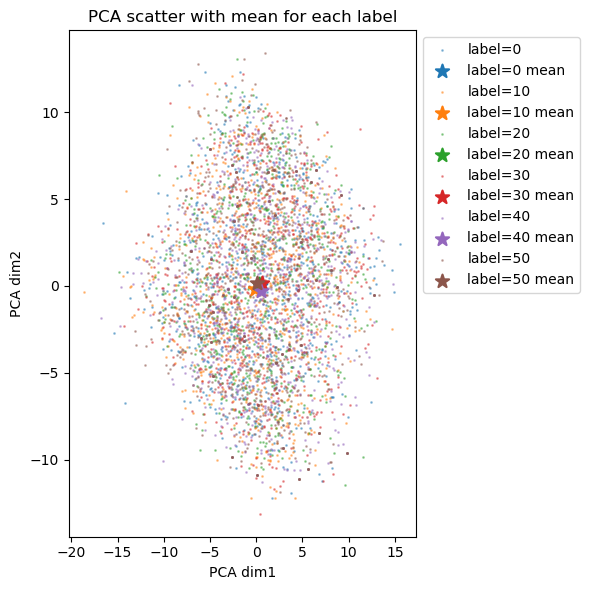

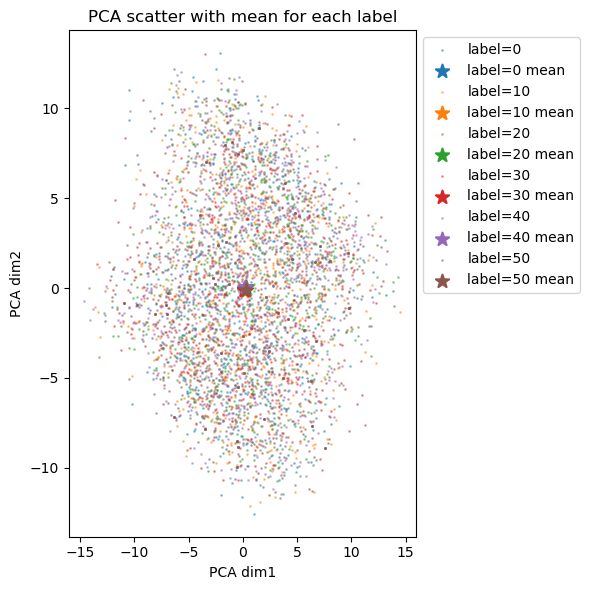

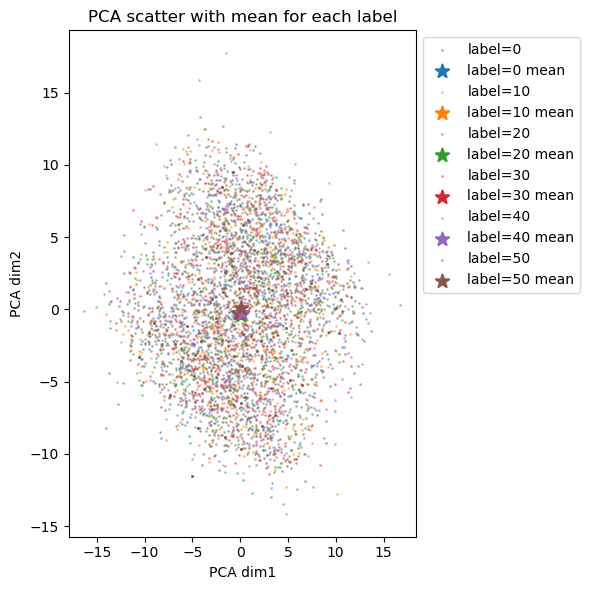

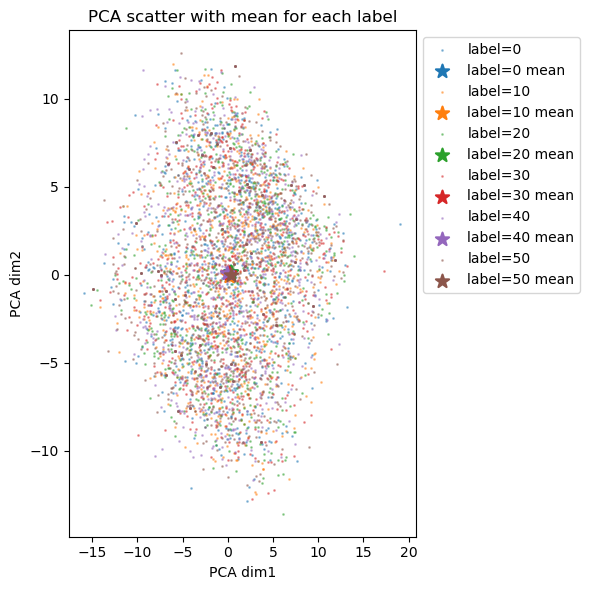

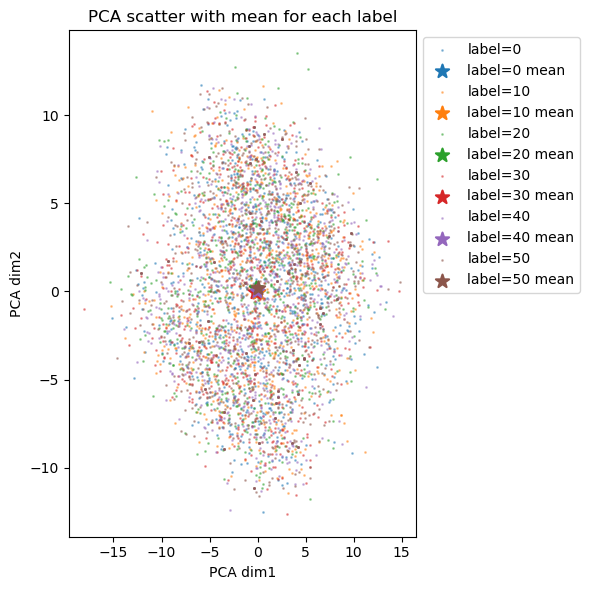

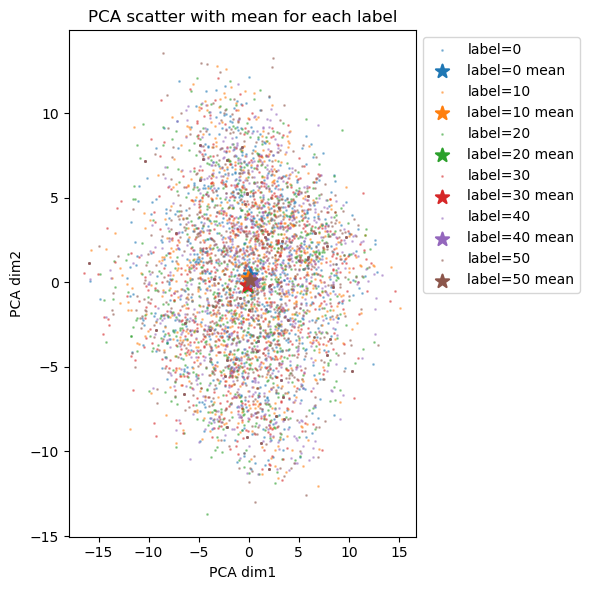

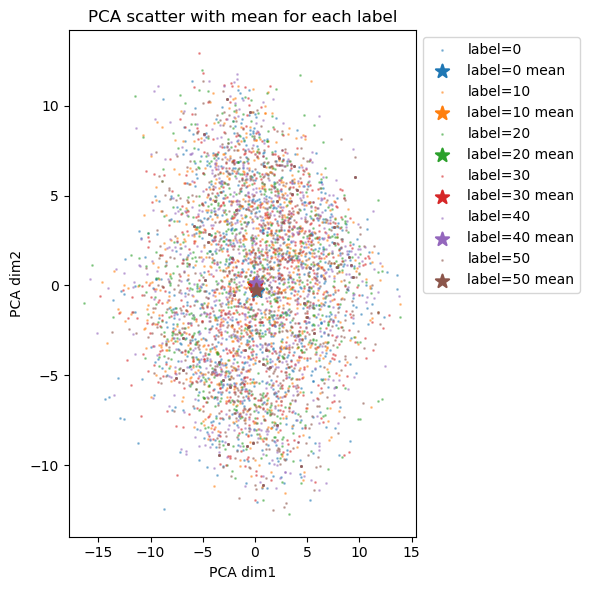

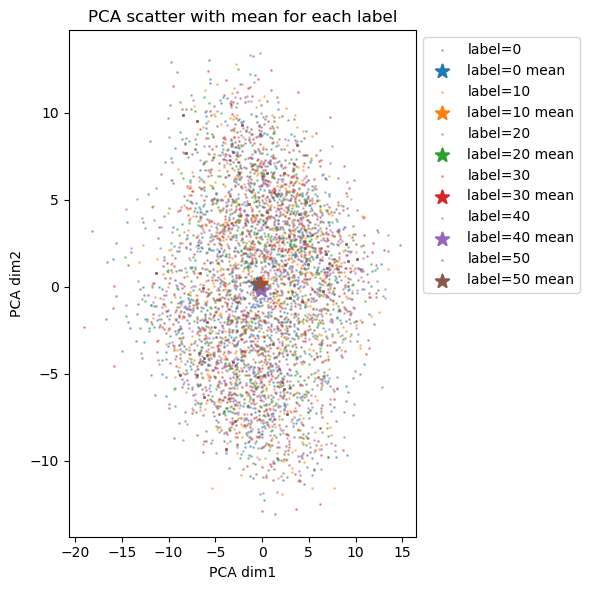

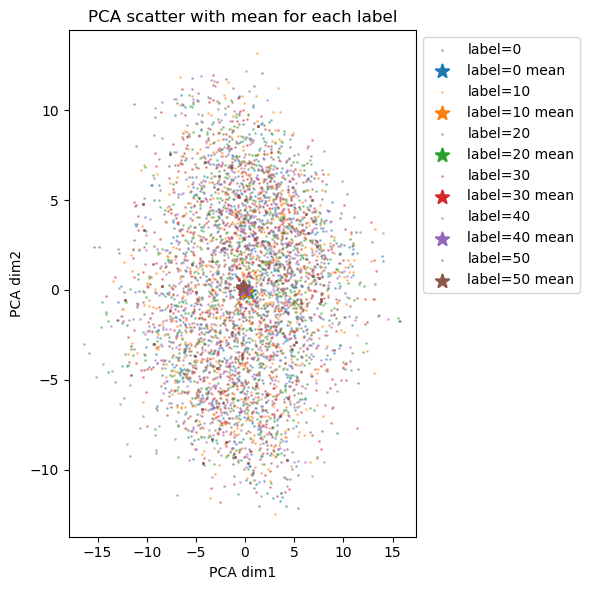

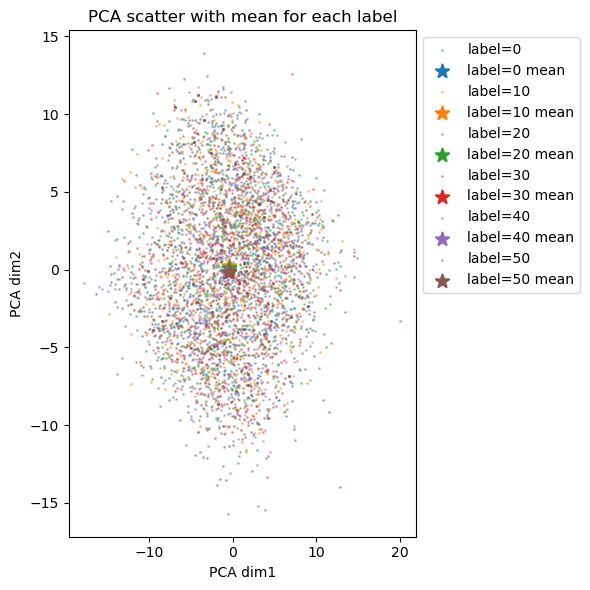

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 全データでPCA行列を学習し、それを用いて各ファイルのデータを2次元に圧縮して散布図を描く
files = [
    "/Users/naokishitanda/my_local_gitcode/sapg2/data/test/data/batches/batch_dict_10.pt",
    "/Users/naokishitanda/my_local_gitcode/sapg2/data/test/data/batches/batch_dict_20.pt",
    "/Users/naokishitanda/my_local_gitcode/sapg2/data/test/data/batches/batch_dict_30.pt",
    "/Users/naokishitanda/my_local_gitcode/sapg2/data/test/data/batches/batch_dict_40.pt",
    "/Users/naokishitanda/my_local_gitcode/sapg2/data/test/data/batches/batch_dict_50.pt",
    "/Users/naokishitanda/my_local_gitcode/sapg2/data/test/data/batches/batch_dict_60.pt",
    "/Users/naokishitanda/my_local_gitcode/sapg2/data/test/data/batches/batch_dict_70.pt",
    "/Users/naokishitanda/my_local_gitcode/sapg2/data/test/data/batches/batch_dict_80.pt",
    "/Users/naokishitanda/my_local_gitcode/sapg2/data/test/data/batches/batch_dict_90.pt",
    "/Users/naokishitanda/my_local_gitcode/sapg2/data/test/data/batches/batch_dict_100.pt",
]

obses_list = []
labels_list = []

# すべてのファイルのデータを読み込んで蓄積
for file in files:
    batch_dict = torch.load(file, map_location=torch.device('cpu'))

    obses = batch_dict['obses'][:, :-1]  # 最後の列以外が特徴量
    labels = batch_dict['obses'][:, -1].int()  # 最後の列がラベル

    obses_list.append(obses)
    labels_list.append(labels)

# 全データを結合して PCA を学習させる
all_obses = torch.cat(obses_list, dim=0)  # (合計サンプル数, 特徴量次元)
pca = PCA(n_components=2)
pca.fit(all_obses)

explained = pca.explained_variance_ratio_
# 軸ラベルに載せるための文字列
x_label = f"PC1 ({explained[0]*100:.2f}% explained var)"
y_label = f"PC2 ({explained[1]*100:.2f}% explained var)"

# カラーマップを用意（ラベルが10種類以内を想定）
cmap = plt.get_cmap('tab10')

# 各ファイルごとに 2 次元散布図を描く
for obses, labels in zip(obses_list, labels_list):
    # このファイルに含まれるサンプルを PCA 空間に変換
    obses_pca = pca.transform(obses)  # shape: (サンプル数, 2)

    plt.figure(figsize=(6, 6))
    unique_labels = labels.unique()

    for i, label in enumerate(unique_labels):
        color = cmap(i % 10)
        idx = (labels == label)
        
        # ラベルごとに散布図 (サンプル点) を描画
        plt.scatter(
            obses_pca[idx, 0], obses_pca[idx, 1],
            s=1, color=color, alpha=0.4,
            label=f"label={label.item()}"
        )

        # ラベルごとの平均を計算して描画
        sub_pca = obses_pca[idx]
        mean_2d = sub_pca.mean(axis=0)

        plt.scatter(
            mean_2d[0], mean_2d[1],
            marker='*', s=100, color=color,
            linewidths=1.5, zorder=3,
            label=f"label={label.item()} mean"
        )

    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.title("PCA scatter with mean for each label")
    plt.xlabel("PCA dim1")
    plt.ylabel("PCA dim2")
    plt.tight_layout()
    plt.show()